In [119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy
import statsmodels.api as sm
from pathlib import Path
from collections import defaultdict
from rapidfuzz import process, fuzz


# Get metabolomics data

In [120]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'


In [121]:
normalization = 'TIC'#
fn1 = metabolomics_folder / f'D_batch_1_4_{normalization}_norm.csv'
df1 = pd.read_csv(fn1)
df1.rename(columns={'metabolite':'Metabolite'}, inplace = True)

In [122]:
fn5 = metabolomics_folder / f'E_batch_5_{normalization}_norm.csv'
df5 = pd.read_csv(fn5)
df5.rename(columns={'metabolite':'Metabolite'}, inplace = True)

In [123]:
df5.ionMz.nunique(), df1.Metabolite.nunique(), len(df5), len(df1)

(1503, 877, 1503, 877)

# Get KEGG IDs
Use KEGG IDs obtained from KEGG directly or iML1515, but skip those from biocyc, seems to contain a lot of strange metabolites

In [124]:
# ecoli_kegg_ids = pd.read_csv(data_folder / 'Z_div/C_all_ecoli_kegg_ids.csv', index_col=0)['KEGG ID'].values
ecoli_kegg_ids = pd.read_csv(data_folder / 'Z_div/C_ecmdb_kegg_ids.csv', header = None)[0].values


In [125]:
len(ecoli_kegg_ids)

1198

# Remove all metabolites that doesn't map to the E. coli metabolome kegg ids


### df1 batch 1-4

In [126]:
# bool_index = np.zeros(len(df), dtype = bool)
keep_idx = []
discarded_mets = []
i_14_to_mapped_kegg_annotations = {}
for i, row in df1.iterrows():
    kegg_annotations = [x.strip(' ') for x in row['KEGG'].split(';')]
    mapped_kegg_annotations = [x for x in kegg_annotations if x in ecoli_kegg_ids]
    i_14_to_mapped_kegg_annotations[i] = ';'.join(mapped_kegg_annotations)
    if len(mapped_kegg_annotations):
        keep_idx.append(i)
    else:
        discarded_mets.append(row['Metabolite'])

In [127]:
df1.insert(2, 'Mapped KEGG',df1.index.map(i_14_to_mapped_kegg_annotations))

In [128]:
df1 = df1.loc[keep_idx]

### df5 batch 5

In [129]:
# bool_index = np.zeros(len(df), dtype = bool)
keep_idx = []
discarded_mets = []
i5_to_mapped_kegg_annotations = {}
for i, row in df5.iterrows():
    kegg_annotations = [x.strip(' ') for x in row['kegg'].split(';')]
    mapped_kegg_annotations = [x for x in kegg_annotations if x in ecoli_kegg_ids]
    i5_to_mapped_kegg_annotations[i] = ';'.join(mapped_kegg_annotations)
    if len(mapped_kegg_annotations):
        keep_idx.append(i)
    else:
        discarded_mets.append(row['Metabolite'])
df5.insert(3, 'Mapped KEGG',df5.index.map(i5_to_mapped_kegg_annotations))
df5 = df5.loc[keep_idx]

In [132]:
# df1.Metabolite.nunique(),
# df5.Metabolite.nunique()

In [134]:
print(df5.ionMz.nunique(), df1.ionMz.nunique(), len(df5), len(df1))

281 246 281 246


# Parse metadata

In [135]:
samples_fn = metabolomics_folder / 'A_samples.csv'
samples_df = pd.read_csv(samples_fn, index_col=0)

# Parse header
And make long dataframe with metadata

## Batch 1-4

In [136]:
# Optional parsing [x.replace(' ','').split('|') for x in df_norm.columns[3:]]
metadata1 = pd.DataFrame([[y.strip(' ') for y in x.split('|')] for x in df1.columns[4:]], columns = ['#/Batch', 'Replicate', 'Strain', 'Timepoint', 'Norm', 'Plate'])



In [137]:
metadata1[['#','Batch']] = metadata1['#/Batch'].str.split(' / ',n=1, expand=True)

In [138]:
metadata1.Timepoint = [f'T{int(x)}' if x!='NaN' else x for x in metadata1.Timepoint]

In [139]:
column_names = metadata1['#/Batch']
df1.columns = list(df1.columns[:4]) + list(column_names)

In [140]:
metadata1.Strain.unique()

array(['STD', 'satP', 'tsx', 'punC', 'yeaS', 'sstT', 'oppA', 'ybjE',
       'rhtA', 'WT', 'ompF', 'ompC', 'ygaZ', 'yddG', 'yedA', 'mscS',
       'adeP', 'ptsG', 'gltJ', 'aroP', 'nagE', 'codB', 'argO', 'actP',
       'setA', 'brnQ', 'lysP', 'putP', 'acrB', 'yhjE', 'mscL', 'glnP',
       'proP', 'cycA', 'gltP', 'gadC', 'rbsC', 'glpF', 'sdaC', 'znuB',
       'focA', 'artQ', 'fruA', 'nupC', 'cstA', 'mtr', 'gltS', 'ugpA',
       'dcuA', 'uhpT', 'nupG', 'pheP', 'tdcC', 'dctA', 'emrB', 'rhtC',
       'dppB', 'galP', 'yahN', 'WT+pEP65', 'metI',
       'ΔtrpC (sfGFP) proB74 + pEP28', 'E.coli MG1655', 'rhtB', 'manY',
       'livH', 'WT+pEP66_5', 'kgtP', 'eamA', 'ansP', 'WT+pEP35', 'hisQ',
       'glpT', 'ΔproC (mCherry) ΔtrpR + pEP28', 'WT+pEP17', 'tolC'],
      dtype=object)

## Batch 5

In [141]:
metadata5 = pd.DataFrame([[y.strip(' ').replace('?', 'Δ') for y in x.split('|')] for x in df5.columns[5:]], columns = ['Batch', 'Replicate', 'Strain', 'Timepoint', 'Plate', 'Well'])

In [142]:
metadata5['#'] = [str(x).zfill(5) for x in np.arange(1, len(metadata5) + 1)]

In [143]:
metadata5['#/Batch'] = metadata5['#']+'/'+metadata5['Batch']

In [144]:
column_names5 = metadata5['#/Batch']
df5.columns = list(df5.columns[:5]) + list(column_names5)

# Make long DFs

In [145]:
df1L = df1.melt(id_vars=['Metabolite', 'ionMz', 'KEGG', 'Mapped KEGG'], var_name='Sample ID', value_name='Peak Intensity')
df5L  = df5.iloc[:,1:].melt(id_vars=['Metabolite', 'ionMz', 'kegg', 'Mapped KEGG'], var_name='Sample ID', value_name='Peak Intensity')


In [146]:
print(df1L.ionMz.nunique(),df5L.ionMz.nunique())

246 281


# Add metadata

In [147]:
df1L = df1L.merge(metadata1, left_on='Sample ID', right_on='#/Batch', how='left')
df5L = df5L.merge(metadata5, left_on='Sample ID', right_on='#/Batch', how='left')



In [148]:
df1L.replace('NaN', np.nan, inplace=True)
df5L.replace('NaN', np.nan, inplace=True)

In [149]:
df1L['Timepoint'] = [float(x.strip('T')) if isinstance(x, str) else x for x in df1L.Timepoint]
df5L['Timepoint'] = df5L['Timepoint'].astype(float)

In [150]:
df5L.rename(columns={'kegg':'KEGG'}, inplace=True)

In [151]:
df1L['Mass-spec run'] = 1
df5L['Mass-spec run'] = 2

In [152]:
df1L.Batch = df1L.Batch.astype(float)
df5L.Batch = df5L.Batch.astype(float)

# Drop batch 5 from df1
and standards after batch 5, plus thw few wrongly annotated samples. Add 10000 to the # in the second run to get unique numbers

In [153]:
df1L = df1L.loc[df1L.Batch != 5]
df1L = df1L.loc[(df1L['#'].astype(int) < 1e4)]
df1L['#'] = df1L['#'].astype(int)
df5L['#'] = df5L['#'].astype(int)
df5L['#'] = df5L['#']+10000

# Subtract instrument drift from batch 1-4

In [154]:
run_drift_correction = False
pi_label = 'Peak Intensity'


In [155]:
if run_drift_correction:
    metabolites = df1L.Metabolite.unique()
    xarr = np.linspace(0, 1e4, 200)
    pi_label = 'Corrected (PI)'
    for i, met in enumerate(metabolites):
        idx = (df1L.Metabolite == met) & (df1L.Timepoint.isin([1,2]))
        x = df1L.loc[idx, '#']
        y = df1L.loc[idx, 'Peak Intensity']
        X = sm.add_constant(x)
        X['x2'] = x**2
        rlm_model = sm.RLM(y,X, M=sm.robust.norms.HuberT())
        rlm_results = rlm_model.fit()
        yarr = rlm_results.params['const'] +xarr*rlm_results.params['#']+xarr**2*rlm_results.params['x2']
        
        idxfit = df1L.Metabolite==met
        x_fit = df1L.loc[idxfit, '#']
        y_all = df1L.loc[idxfit, 'Peak Intensity']
        y_fit = rlm_results.params['const'] + x_fit*rlm_results.params['#']+x_fit**2*rlm_results.params['x2']
        df1L.loc[idxfit, 'Corrected (PI)'] = y_all - y_fit
    # if i > j:
    #     print(met)
    #     break

# plt.plot(x_fit, y_fit)
# plt.plot(x_fit, y_all, 'o', alpha = 0.3)
# plt.plot(x_fit, y_all - y_fit, 'o', alpha = 0.3)

# Remove standards and NaN

In [156]:
df1L = df1L.loc[df1L.Strain != 'STD'].copy()
# df5L = df5L.loc[df5L.Strain != 'STD']
df5L = df5L.loc[df5L.Strain != 'blank'].copy()

df1L.dropna(subset=['Peak Intensity'], inplace=True)
df5L.dropna(subset=['Peak Intensity'], inplace=True)

<Axes: xlabel='#', ylabel='Peak Intensity'>

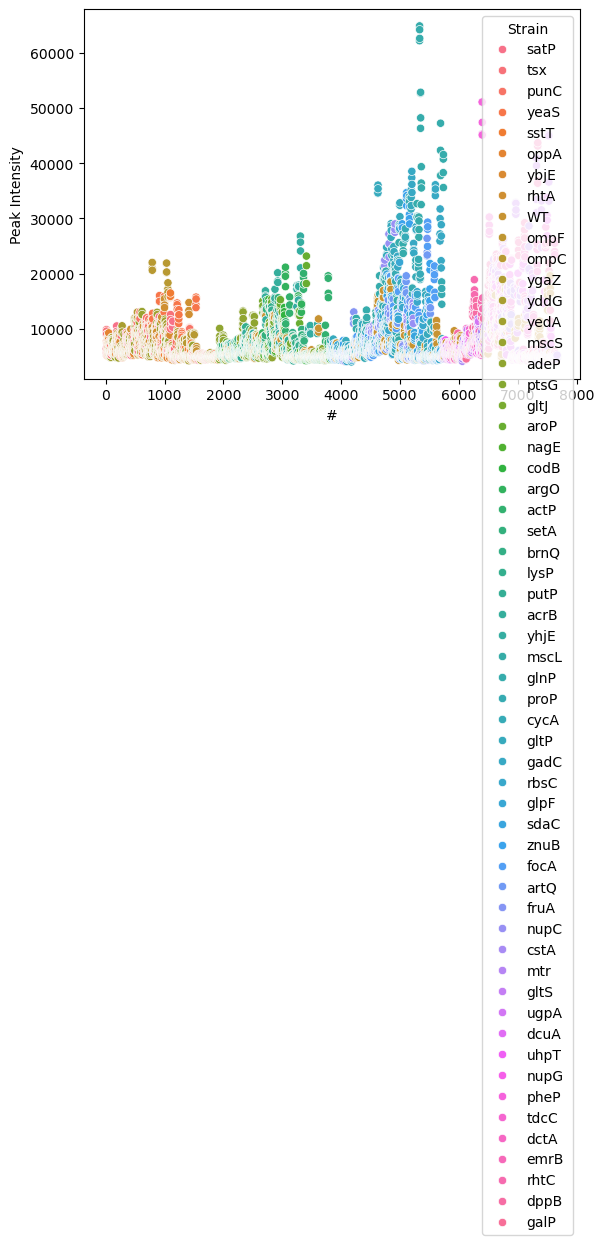

In [157]:
sns.scatterplot(df1L.loc[df1L.Metabolite=='Glutathione; Stealthin C'], x = "#", y = pi_label, hue = 'Strain')

# Remove outliers
From df1

In [158]:
def remove_outliers(df, outliers):
    idx_list = []
    for i, outlier_lst in enumerate(outliers):
        
        idxo = (df['#'].isin([int(x) for x in outlier_lst[2]]))&(df.Metabolite==outlier_lst[1])&(df.Strain==outlier_lst[0])
        if np.sum(idxo)==0:
            print('Warning: No outliers found for', outlier_lst)
        if i == 0:
            idx = idxo
        else:
            idx = idx | idxo
    print(f'Remove {np.sum(idx)} datapoints')
    return df.loc[~idx]
    
outliers = [
    ['punC', 'Taurine', ['00029', '00030','00031', '00032']],
    ['punC', 'S-Ribosyl-L-homocysteine', ['00029', '00030','00031', '00032']],
    ['punC', '3-Sulfino-L-alanine', ['00029', '00030','00031', '00032']],
    ['punC', 'Glycine', ['00029', '00030','00031', '00032', '00069', '00070', '00071', '00072']],
    ['punC', 'Pyridoxamine', ['00017', '00018', '00019', '00020', '00029', '00030','00031', '00032', '00033', '00034','00035', '00036']],
    ['punC', 'Acetylornithine', ['01637', '01638', '01639', '01640']],
    ['punC', 'Arginine', ['01637', '01638', '01639', '01640']],
    ['punC', 'Citrulline', ['01637', '01638', '01639', '01640']],
    ['punC', 'Ornithine', ['01637', '01638', '01639', '01640']],
    ['punC', 'IMP', ['01637', '01638', '01639', '01640']],
    ['punC', '(Iso)Citrate', ['01637', '01638', '01639', '01640']],
    ['punC', '7,8-Diaminononanoate', ['01637', '01638', '01639', '01640']],
    ['punC', 'Serine', ['01749', '01750', '01751', '01752', '01125','01126', '01127', '01128']],
    ['punC', 'Histidine', ['01749', '01750', '01751', '01752', '01125','01126', '01127', '01128']],
    
    ['tsx', 'CTP', ['00253', '00254', '00255', '00256']],
    ['tsx', 'D-Ribose 5-diphosphate', ['00253', '00254', '00255', '00256']],
    ['tsx', 'Disaccharide', ['01273', '01274', '01275', '01276']],
    ['tsx', 'Pyridoxamine', ['00013', '00014', '00015', '00016', '00093', '00094','00095', '00096']],
    
    ['artQ', 'FGAR', ['04044', '04045', '04046', '04047']],
    ['artQ', '(E)-4-(Trimethylammonio)but-2-enoate', ['04044', '04045', '04046', '04047']],

    ['argO', 'Glycerol', ['02901', '02902', '02903', '02904']],
    ['codB', 'Glycerol', ['02913', '02914', '02915', '02916']],
    
    ['rhtA', 'Urate', ['00169', '00170', '00171', '00172']],
    ['rhtA', 'Acetylornithine', ['01917', '01918', '01919', '01920']],
    ['rhtA', 'Arginine', ['01917', '01918', '01919', '01920']],
    ['rhtA', 'Hexanoic acid', ['01917', '01918', '01919', '01920']],
    ['rhtA', '3-Dehydroquinate', ['01105', '01106', '01107', '01108']],
    ['rhtA', 'sn-Glycero-3-phosphocholine', ['01105', '01106', '01107', '01108']],
    ['rhtA', 'Phenyl acetate', ['01105', '01106', '01107', '01108']],
    ['rhtA', 'Phosphoglycerate', ['01105', '01106', '01107', '01108']],
    ['rhtA', '(Iso)Citrate', ['01917', '01918', '01919', '01920']],
    
    
    ['ompF', 'Glycine', ['00273', '00274', '00275', '00276']],
    ['ompF', 'Urate', ['00273', '00274', '00275', '00276']],
    ['ompF', 'Phosphoglycerate', ['01077', '01078', '01079', '01080']],

    ['oppA', 'Glutathione disulfide', ['00225', '00226', '00227', '00228']],
    ['oppA', 'Cys', ['00057', '00058']],
    ['oppA', '4-Methyl-2-oxopentanoate', ['01909']],
    ['oppA', 'O-Phospho-4-hydroxy-L-threonine', ['00175']],
    ['oppA', '6-Acetyl-D-glucose', ['01909', '01910']],
    ['oppA', 'N-Acetylneuraminate', ['01909']],
    
    
    ['emrB', 'Histidine', ['06209', '06210']],
    ['emrB', 'Serine', ['06209', '06210']],
    ['emrB', 'Ornithine', ['06209','06210']],
    ['sdaC', 'Serine', ['04940', '04941', '04942', '04943', '04930', '04931']],
    # ['tolC', 'Serine', ['09232', '09233']],
    # ['tolC', 'Histidine', ['09232', '09233']],
    # ['tolC', 'Ornithine', ['09232', '09233']],
    ['nupG', 'Serine', ['06313', '06314']],
    ['nupC', 'Serine', ['04814','04815', '05258', '05259']],
    ['yedA', 'Phenylacetaldehyde', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Phenyl acetate', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', '3-Dehydroquinate', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Ketovaline', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Glutamine', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Glycine', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092', '00261', '00262','00263', '00264']],
    ['yedA', 'N-Acetyl-D-glucosamine', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Met-oxide', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'sn-Glycero-3-phosphocholine', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', '2-Aceto-2-hydroxybutanoate', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'dTDP-hexose', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Deoxyhexose', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Pyridoxamine', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Urate', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Nicotinamide', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Benzyl alcohol', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', '3-Sulfino-L-alanine', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', '(E)-4-(Trimethylammonio)but-2-enoate', ['00213', '00214','00215','00216', '00089', '00090', '00091', '00092']],
    ['yedA', 'Pyridoxine', ['00089', '00090', '00091', '00092']],
    ['yedA', 'Hexanoic acid', ['00089', '00090', '00091', '00092']],
    ['yedA', 'Cytosine', ['00089', '00090', '00091', '00092']],

    ['ybjE', 'Histidine', ['01091', '01092', '00383', '00384']],
    ['ybjE', 'Serine', ['01091', '01092', '00383', '00384']],

    ['yddG', 'FGAR', ['00081', '00082', '00083', '00084']],

    ['yeaS', 'Pyridoxamine', ['00021', '00022', '00023', '00024', '00075', '00076']],
    ['yeaS', 'Phenylacetaldehyde', ['00993', '00994', '00995', '00996']],

    ['ygaZ', 'Histidine', ['00305', '00306', '00307', '00308']],
     

    
    ['satP', 'Pyridoxamine', ['00009', '00010', '00011', '00012']],
    ['satP', 'N-Acetyl-D-glucosamine', ['00009', '00010', '00011', '00012']],
    ['satP', 'Met-oxide', ['00010', '00012']],

    ['mscS','Phosphoglycerate', ['01075','01076']],
    
    ['WT', 'Glycine', ['00293', '00294', '00295', '00296', '00325', '00326', '00327', '00328', '00337', '00338', '00339','00340']],
    ['WT', 'Serine', ['06221', '06222', '01691','01692','04946']],
    ['WT', 'Histidine', ['06221', '06222', '01691','01692','04946']],
    ['WT', 'Succinyl-CoA', ['00313', '00314', '00315','00316']],   
]
df1L = remove_outliers(df1L, outliers)


Remove 413 datapoints


# Normalize

In [159]:
for mz in df1L.ionMz.unique():
    idx = (df1L.ionMz == mz)
    mean = df1L.loc[idx, pi_label].mean()
    std = df1L.loc[idx, pi_label].std()
    df1L.loc[idx, 'Z-score'] = (df1L.loc[idx, pi_label]-mean)/std

for mz in df5L.ionMz.unique():
    idx = (df5L.ionMz == mz)
    mean = df5L.loc[idx, pi_label].mean()
    std = df5L.loc[idx, pi_label].std()
    df5L.loc[idx, 'Z-score'] = (df5L.loc[idx, pi_label]-mean)/std

# Merge

In [160]:
df5L.Strain.replace('E.coli MG1655', 'E. coli MG1655', inplace=True)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_69672/4038160692.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df5L.Strain.replace('E.coli MG1655', 'E. coli MG1655', inplace=True)


In [161]:
df1L['Mass-spec run'] = 1
df5L['Mass-spec run'] = 2
df = pd.concat([df1L,df5L])

In [162]:
df.drop(columns=['#/Batch', 'Norm'], inplace=True)

# Get OD data

In [163]:
od_fn = metabolomics_folder / 'F_od_and_auc.csv'
od_df = pd.read_csv(od_fn, index_col=0)

In [164]:
strains = sorted([x for x in od_df['Strain'].unique()])

# Merge OD and metabolomics

In [165]:
plate_well_to_medium = defaultdict(lambda: 'M9 20 mM glucose pH 7.4')
temp_dict = samples_df.set_index(['Plate', 'Well'])['Medium'].to_dict()
plate_well_to_medium.update(temp_dict)

### Fix columns before merge

In [166]:
od_df.replace({'Timepoint':'nan'}, np.nan, inplace=True)
od_df['Timepoint'] = [float(x.strip('T')) if isinstance(x, str) else x for x in od_df.Timepoint]


In [167]:
df['Well'] = [x.split('.')[0] if isinstance(x, str) else x for x in df['Well']]


In [168]:
df['Medium'] = df.apply(lambda x: plate_well_to_medium[x['Plate'], x['Well']], axis=1)


In [169]:
df_full = pd.merge(left = df, right = od_df, left_on=('Strain','Replicate','Timepoint', 'Batch', 'Medium'), right_on=('Strain', 'Parallel', 'Timepoint', 'Batch', 'Medium'), how='left')



# Get median of the four technical replicates

In [170]:
df_average = df_full.groupby(['Batch-Tube', 'Timepoint', 'ionMz','Metabolite','Mapped KEGG', 'KEGG', 'Medium']).agg({'Z-score':('mean','std','median'),'OD':'first', 'AUC OD':'first', 'Hours':'first', 'Strain':'first', 
                                                                    'Parallel':'first', 'Batch':'first', 
                                                                    '#':'first', 'Exp. phase time limit':'first', 'Tube':'first','Well':'first'}).reset_index()


In [171]:
df_average.columns = ['Batch-Tube', 'Timepoint', 'ionMz','Metabolite', 'Mapped KEGG', 'KEGG', 'Medium', 'Z-score mean', 'Z-score std', 'Z-score median', 'OD', 'AUC OD', 'Hours', 'Strain','Parallel', 'Batch', '#', 'Exp. phase time limit', 'Tube', 'Well']

### Get median of non-standardised data

In [172]:
df_average_pi = df_full.groupby(['Batch-Tube', 'Timepoint', 'ionMz','Metabolite','Mapped KEGG', 'KEGG', 'Medium']).agg({'Peak Intensity':('mean','std','median'),'OD':'first', 'AUC OD':'first', 'Hours':'first', 'Strain':'first',
                                                                    'Parallel':'first', 'Batch':'first', 
                                                                    '#':'first', 'Exp. phase time limit':'first', 'Tube':'first'}).reset_index()
df_average_pi.columns = ['Batch-Tube', 'Timepoint', 'ionMz','Metabolite', 'Mapped KEGG', 'KEGG', 'Medium', 'PI mean', 'PI std', 'PI median', 'OD', 'AUC OD', 'Hours', 'Strain','Parallel', 'Batch', '#', 'Exp. phase time limit', 'Tube']

# Save median values
Without metadata to save space.
Separate data into KEIO KOs and others

In [173]:
MG1655_strains = ['WT+pEP35', 'WT+pEP17', 'ΔproC (mCherry) ΔtrpR + pEP28', 'ΔtrpC (sfGFP) proB74 + pEP28',
       'WT+pEP65', 'WT+pEP66_5', 'E. coli MG1655']

In [174]:
df_keio = df_average.loc[~df_average.Strain.isin(MG1655_strains)].copy()
df_others = df_average.loc[df_average.Strain.isin(MG1655_strains)].copy()

In [175]:
df_average_pi = df_average_pi.loc[~df_average_pi.Strain.isin(MG1655_strains)]
df_average_pi = df_average_pi.loc[df_average_pi.Strain != 'mscS']
df_average_pi[['Batch-Tube', 'Timepoint', 'ionMz', 'PI median', 'PI std']].to_csv(metabolomics_folder / f'G_median_PI_{normalization}_norm_keio.csv', index = False)

## Remove mscS because it is likely the wrong strain

In [176]:
df_keio = df_keio.loc[df_keio.Strain != 'mscS'].copy()  # Remove likely wrong strain

In [177]:
data_others = df_others[['Batch-Tube', 'Timepoint', 'ionMz', 'Z-score median', 'Z-score std']]
data_keio = df_keio[['Batch-Tube', 'Timepoint', 'ionMz', 'Z-score median', 'Z-score std']]


In [178]:
fn_others = metabolomics_folder / f'G_median_z_scores_{normalization}_norm_others.csv'
data_others.to_csv(fn_others, index=False)

fn_keio = metabolomics_folder / f'G_median_z_scores_{normalization}_norm_keio.csv'
data_keio.to_csv(fn_keio, index=False)

# Save metadata
ionMZ and sample metdata seperately

### Load KEGG mapping

In [193]:
mapping_folder = repo_folder / 'data'/ 'this_project' / '6_transporterKO' / 'Z_div'
# fn_kegg_mapping = mapping_folder / 'D_kegg_mapping_metaboanalyst.csv'
fn_kegg_mapping = mapping_folder / 'D_ecmdb_metabolite_info.csv'
df_km = pd.read_csv(fn_kegg_mapping)

In [194]:
mz_annotation_df = df_average[['ionMz', 'Metabolite', 'Mapped KEGG', 'KEGG']].drop_duplicates().reset_index(drop=True)

In [196]:
for i, row in mz_annotation_df.iterrows():
    kegg_ids = [x.strip(' ') for x in row['Mapped KEGG'].split(';') if x.strip(' ')]
    names = []
    for kid in kegg_ids:
        names += df_km.loc[df_km['kegg_id'] == kid, 'name'].tolist()
    names = [x for x in names if isinstance(x, str) and len(x)>0]
    names = [x.replace('DL-', '').replace('L-', '').replace('D-', '') for x in names]
    if not len(names) and len(kegg_ids):
        names = [row['Metabolite']]
    mz_annotation_df.loc[i, 'Mapped names'] = ' / '.join(sorted(set(names)))

In [197]:
mz_annotation_df

,ionMz,Metabolite,Mapped KEGG,KEGG,Mapped names
0,57.0346,Acetone,C00479,C00207; C00479; C02001; C11506; C11507; C15508,Propanal
1,59.0135,Acetatic acid,C00033;C00266,C00033; C00266,Acetic acid / Glycolaldehyde
2,71.0141,Propenoic acid C3:1,C00546,C00511; C00546; C19246; C19297; C19440,Pyruvaldehyde
3,72.0093,Iminoacetate,C15809,C15809,2-iminoacetate
4,72.9932,Glyoxylic acid,C00048,C00048,Glyoxylic acid
...,...,...,...,...,...
493,861.6729,Ubiquinone-10,C11378,C11378,Ubiquinone-10
494,863.2971,Precorrin 2,C02463,C02463,Precorrin 2
495,864.1473,2-Methylacetoacetyl-CoA,C03344,C03344,2-Methylacetoacetyl-CoA
496,974.2935,trans-Tetradec-2-enoyl-CoA,C05273,C05273; C06736; C06737,(2E)-Tetradecenoyl-CoA


# Use mapped KEGG IDs to remove "Metabolite" names that are not correct


In [198]:
nucleotide_abbrv = ['GMP', 'AMP', 'CMP', 'UMP', 'TMP', 'dTDP', 'dUTP', 'dITP', 'UDP', 'UMP', 'dTMP',
'GTP', 'GDP', 'UTP', 'CTP', 'IMP'] 

In [199]:
for i, row in mz_annotation_df.iterrows():
    metabolites = [x.strip() for x in row['Metabolite'].split(';')]
    mapped_names = [x.strip() for x in row['Mapped names'].split('/')]
    keep = []
    for m in metabolites:
        if m in nucleotide_abbrv:
            keep.append(m)
            continue
        if m.split('-')[0] in nucleotide_abbrv:
            keep.append(m)
            continue

        fuzz_match = process.extract(m, mapped_names, scorer=fuzz.partial_token_set_ratio)
        fuzz_match_acid = process.extract(m.rstrip('ate')+'ic acid', mapped_names, scorer=fuzz.token_set_ratio)
        fuzz_match.extend(fuzz_match_acid)
        if len(fuzz_match) and max([x[1] for x in fuzz_match]) >= 70:
            keep.append(m)
        else:
            print(f"Removing {m} from ionMz {row['ionMz'], row['Mapped names']} due to no match")
    if not len(keep):
        keep.append(mapped_names[0])
    mz_annotation_df.at[i, 'Kept names'] = keep[0]
        # print(f"Keeping first mapped name {keep} for ionMz {row['ionMz'], row['Mapped names']}")
    

Removing Acetone from ionMz (57.0346, 'Propanal') due to no match
Removing Propenoic acid C3:1 from ionMz (71.0141, 'Pyruvaldehyde') due to no match
Removing Succinic aldehyde from ionMz (85.0297, 'Diacetyl') due to no match
Removing Homoserine lactone from ionMz (100.0407, '2-Aminobut-2-enoate') due to no match
Removing Pyruvate oxime from ionMz (102.0199, '2-Aminomalonate semialdehyde / Peroxyaminoacrylate') due to no match
Removing Hexanoic acid from ionMz (115.0767, 'Hexanoate (N-C6:0)') due to no match
Removing Dihydro-4,4-dimethyl-2,3-furandione from ionMz (127.0403, '2-Hydroxy-cis-hex-2,4-dienoate') due to no match
Removing Oxoproline from ionMz (128.0353, 'Pyrrolidonecarboxylic acid / Pyrroline hydroxycarboxylic acid') due to no match
Removing Anthranilate from ionMz (136.0404, '2-Aminobenzoic acid / p-Aminobenzoic acid') due to no match
Removing (E)-4-(Trimethylammonio)but-2-enoate from ionMz (142.0873, 'Crotonobetaine / Stachydrine') due to no match
Removing Acetylcholine fro

In [200]:
mz_annotation_df['Metabolite'] = mz_annotation_df['Kept names']
mz_annotation_df['KEGG'] = mz_annotation_df['Mapped KEGG']
mz_annotation_df['All metabolite names'] = mz_annotation_df['Mapped names']
mz_annotation_df.drop(columns=['Mapped names', 'Kept names', 'Mapped KEGG'], inplace=True)


In [201]:
mz_annotation_df.to_csv(metabolomics_folder / f'H_ionMz_annotation.csv', index=False)

## Sample metadata

In [202]:
others_metadata = df_others[['Batch-Tube', 'Timepoint', 'Medium', 'OD', 'AUC OD', 'Hours', 'Strain','Parallel', 'Batch', '#', 'Exp. phase time limit', 'Tube', 'Well']].drop_duplicates().reset_index(drop=True)
keio_metadata = df_keio[['Batch-Tube', 'Timepoint', 'Medium', 'OD', 'AUC OD', 'Hours', 'Strain','Parallel', 'Batch', '#', 'Exp. phase time limit', 'Tube', 'Well']].drop_duplicates().reset_index(drop=True)

In [203]:
others_metadata.to_csv(metabolomics_folder / f'I_sample_metadata_others.csv', index=False)
keio_metadata.to_csv(metabolomics_folder / f'I_sample_metadata_keio.csv', index=False)

# Name to mz mapping

In [204]:

name_to_mz = defaultdict(set)
for _, row in mz_annotation_df.iterrows():
    for name in row['All metabolite names'].split(' / '):
        name_to_mz[name].add(row['ionMz'])

# Convert to DataFrame for easier viewing
name_mz_df = pd.DataFrame([
    {'Name': name, 'ionMz': ';'.join((str(x) for x in mzs))}
    for name, mzs in name_to_mz.items()
])
name_mz_df.to_csv(data_folder / 'Z_div/H_name_to_mz.csv', index = False)

In [205]:
name_mz_df

,Name,ionMz
0,Propanal,57.0346;57.0342
1,Acetic acid,59.0135
2,Glycolaldehyde,59.0135
3,Pyruvaldehyde,71.0137;71.0141
4,2-iminoacetate,72.0093
...,...,...
588,Precorrin-1,849.2765
589,Ubiquinone-10,861.6729
590,Precorrin 2,863.2971
591,(2E)-Tetradecenoyl-CoA,974.2935


In [209]:
df_keio.ionMz.nunique(), df_others.ionMz.nunique(), df_average.ionMz.nunique(), df_full.ionMz.nunique(), mz_annotation_df.ionMz.nunique(), len(mz_annotation_df)

(494, 281, 494, 494, 494, 498)

In [211]:
df5L.Strain.unique()

array(['WT+pEP66_5', 'WT+pEP35', 'ΔtrpC (sfGFP) proB74 + pEP28', 'glpT',
       'tolC', 'WT', 'WT+pEP65', 'WT+pEP17', 'metI',
       'ΔproC (mCherry) ΔtrpR + pEP28', 'E. coli MG1655', 'livH', 'ansP',
       'yahN', 'hisQ', 'kgtP', 'eamA', 'rhtB', 'manY'], dtype=object)